In [2]:
import pickle
import os
import matplotlib.pyplot as plt
import numpy as np
import jax.numpy as jnp
import pandas as pd

%env XLA_PYTHON_CLIENT_PREALLOCATE=False

PKLs = []
PKL_titles = []
DIR = "./output_28_dim10_mean0_test/"
for file in os.listdir(DIR):
    if file.endswith(".pkl") and "merge" in file:
        PKLs.append(pickle.load(open(DIR+file, "rb")))
        PKL_titles.append(str(file))
n = len(PKLs)
plt.rcParams['text.usetex'] = False

env: XLA_PYTHON_CLIENT_PREALLOCATE=False


In [3]:
idx_proposal = dict()
for i in range(n):
    proposal = PKLs[i]['config']['proposal']
    idx_proposal[proposal] = idx_proposal.get(proposal, []) + ([i])


In [4]:
i=1
max_size = PKLs[i]['res'][6].shape[1]
num_para = PKLs[i]['res'][6].shape[0]
max_temp_idx = max([jnp.min(jnp.argwhere(PKLs[i]['res'][6]==1), axis=0)[1] for i in range(n)])

log_normalization_constants = {proposal: [PKLs[idx]['res'][8].reshape(num_para, max_size)[..., 1: max_temp_idx] for idx in idx_proposal[proposal]] for proposal in idx_proposal}



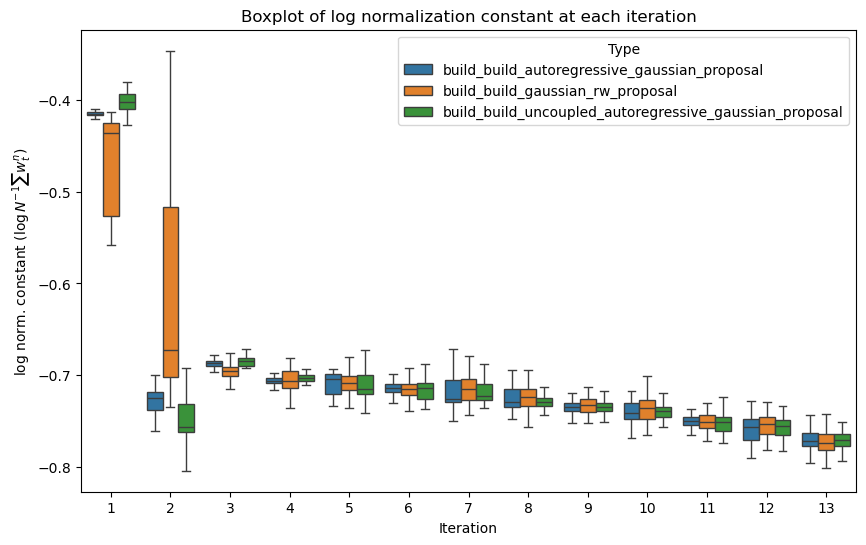

In [6]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

#construct all dfs

my_dfs = {proposal: 
              [
                  pd.DataFrame(log_normalization_constants[proposal][idx], columns=list(range(1, max_temp_idx))).assign(Type=proposal) 
                  for idx in range(len(idx_proposal[proposal]))]
           for proposal in idx_proposal
         }

#


# Combine the DataFrames
combined_df = pd.concat([pd.concat([df for df in my_dfs[proposal]]) for proposal in idx_proposal])

# Melt the combined DataFrame to long-form
melted_df = combined_df.melt(id_vars=['Type'], var_name='Variable', value_name='Value')


# Create the boxplot
plt.figure(figsize=(10, 6))
sns.boxplot(x='Variable', y='Value', hue='Type', data=melted_df, showfliers=False)

# Add titles and labels
plt.title('Boxplot of log normalization constant at each iteration')
plt.xlabel('Iteration')
plt.ylabel(r'log norm. constant ($\log N^{-1} \sum w_t^n$)')

# Show the plot
plt.savefig(DIR+"boxplot.png")